# Description

"Where are editing sites located?"

## Useful links

Pyranges python library for manipulation of genomic data: https://pyranges.readthedocs.io/en/latest/

Dataset: https://rediportal.cloud.ba.infn.it/atlas/index.html

In [ ]:
# select the right kernel

import sys
print(sys.executable)

/scr/kronos/bioinf/rna_editing_project/.venv/bin/python


# Load REDIportal dataset

In [31]:
import pandas as pd
from pathlib import Path

DATA = Path("../data/TABLE1_hg38_v3.txt")

# read the data into a pandas DataFrame
df = pd.read_csv(DATA, sep="\t")
# print the shape of the dataframe
n_rows, n_cols = df.shape

print(f"Number of editing sites: {n_rows:,}")
print(f"Number of columns: {n_cols}")

Number of editing sites: 749,926
Number of columns: 43


# Dataset overview

In [12]:
# print the rows of the dataframe
df.head()

,Accession,Region,Position,Ref,Ed,Strand,db,type,dbsnp,repeat,...,rnacentral,nTCGASamples,nTCGAPrj,sTCGAprj,sTCGAdiseasetype,nTCGAdiseasetype,PlotsTCGA,PRIDE,REDInet_BS,REDInet_mean
0,EDHSAAAA0000,chr1,87158,T,C,-,A,ALU,-,SINE/AluJo,...,-,0.0,0.0,0,0,0.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.0
1,EDHSAAAA0001,chr1,87168,T,C,-,A,ALU,-,SINE/AluJo,...,-,0.0,0.0,0,0,0.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.0
2,EDHSAAAA0002,chr1,87171,T,C,-,A,ALU,-,SINE/AluJo,...,-,2.0,2.0,101000000000000000000,100000000001000000000000,2.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.0
3,EDHSAAAA0003,chr1,87189,T,C,-,A,ALU,-,SINE/AluJo,...,-,0.0,0.0,0,0,0.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.0
4,EDHSAAAA0004,chr1,87218,T,C,-,A,ALU,-,SINE/AluJo,...,-,1.0,1.0,10000000000,100000000000000000000000,1.0,"0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,0-0,0,0,0,0,...",-,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-...",-1.0


In [14]:
# print the columns of the dataframe
df.columns.tolist()

['Accession',
 'Region',
 'Position',
 'Ref',
 'Ed',
 'Strand',
 'db',
 'type',
 'dbsnp',
 'repeat',
 'Func.wgEncodeGencodeBasicV45',
 'Gene.wgEncodeGencodeBasicV45',
 'ExonicFunc.wgEncodeGencodeBasicV45',
 'AAChange.wgEncodeGencodeBasicV45',
 'Func.refGene',
 'Gene.refGene',
 'ExonicFunc.refGene',
 'AAChange.refGene',
 'Func.knownGene',
 'Gene.knownGene',
 'ExonicFunc.knownGene',
 'AAChange.knownGene',
 'phastConsElements100way',
 'nSamples',
 'nTissues',
 'sTissue',
 'sBody',
 'nBodySites',
 'PlotsBody',
 'geneID',
 'geneType',
 'geneTag',
 'uniprotID',
 'rnacentral',
 'nTCGASamples',
 'nTCGAPrj',
 'sTCGAprj',
 'sTCGAdiseasetype',
 'nTCGAdiseasetype',
 'PlotsTCGA',
 'PRIDE',
 'REDInet_BS',
 'REDInet_mean']

In [15]:
# print the info of the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 749926 entries, 0 to 749925
Data columns (total 43 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Accession                           749926 non-null  str    
 1   Region                              749926 non-null  str    
 2   Position                            749926 non-null  int64  
 3   Ref                                 749926 non-null  str    
 4   Ed                                  749926 non-null  str    
 5   Strand                              749926 non-null  str    
 6   db                                  749926 non-null  str    
 7   type                                749926 non-null  str    
 8   dbsnp                               749926 non-null  str    
 9   repeat                              749926 non-null  str    
 10  Func.wgEncodeGencodeBasicV45        749926 non-null  str    
 11  Gene.wgEncodeGencodeBasicV45        7

## Genomic annotation

Determine the genomic distribution of RNA editing sites.

In [ ]:
# whether sites are mostly intronic, exonic, UTRs, etc. in %
(
    df["Func.refGene"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Func.refGene
intronic          65.52
intergenic        22.72
ncRNA_intronic     4.80
UTR3               3.59
downstream         1.84
upstream           0.78
ncRNA_exonic       0.53
exonic             0.12
UTR5               0.10
splicing           0.00
ncRNA_splicing     0.00
Name: proportion, dtype: float64

<Axes: xlabel='Func.refGene'>

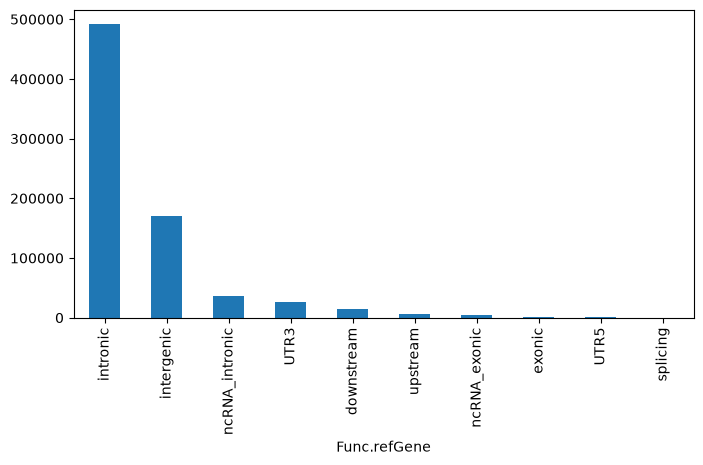

In [34]:
df["Func.refGene"].value_counts().head(10).plot.bar(figsize=(8,4))

### Observation
Most edited sites are intronic

# Repeat annotations

In [ ]:
# in %

(
    df["repeat"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

repeat
SINE/AluJb                     12.67
SINE/AluSx                     10.49
SINE/AluSx1                    10.38
SINE/AluSz                      9.77
SINE/AluJr                      6.11
                               ...  
Simple_repeat/(TCTTTC)n         0.00
LTR/HERVH-int                   0.00
LTR/LTR1D1                      0.00
Simple_repeat/(TATGTATATG)n     0.00
DNA/Cheshire                    0.00
Name: proportion, Length: 510, dtype: float64

<Axes: xlabel='repeat'>

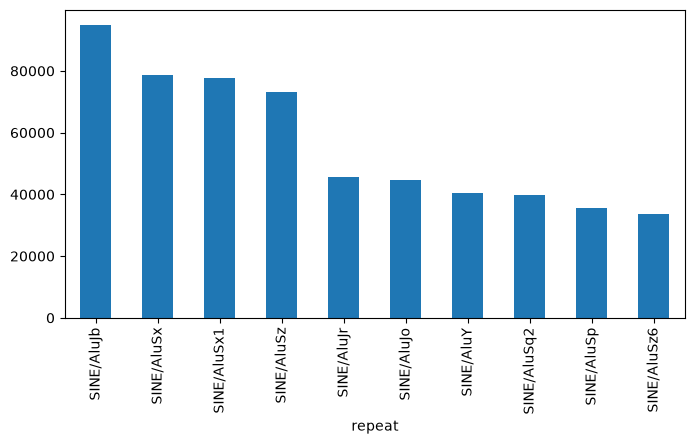

In [35]:
df["repeat"].value_counts().head(10).plot.bar(figsize=(8,4))

### Observation 

Most editing sites occur within Alu repeats.

# Editing statistics

In [23]:
df["REDInet_mean"].describe()

count    749925.000000
mean         -0.527172
std           0.848702
min          -1.000000
25%          -1.000000
50%          -1.000000
75%          -1.000000
max           1.000000
Name: REDInet_mean, dtype: float64

mkdir -p failed for path /home/mescalin/bioinf/.config/matplotlib: [Errno 13] Permission denied: '/home/mescalin/bioinf/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-jpl5i0qy because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


<Axes: >

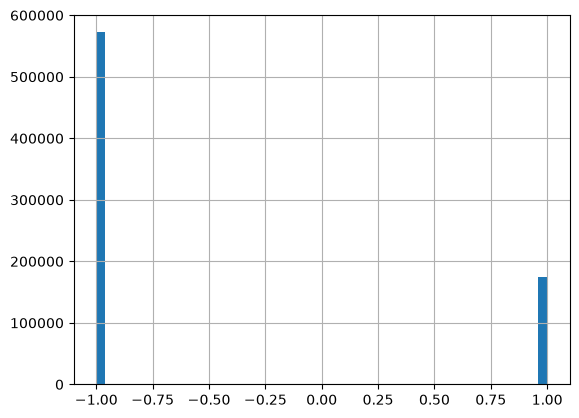

In [24]:
df["REDInet_mean"].hist(bins=50)

In [17]:
# check for missing values in the dataframe
df.isna().sum().sort_values(ascending=False).head(20)

nTCGASamples                    1
uniprotID                       1
geneTag                         1
PlotsTCGA                       1
PRIDE                           1
sTCGAdiseasetype                1
nTCGAdiseasetype                1
REDInet_BS                      1
REDInet_mean                    1
sTCGAprj                        1
nTCGAPrj                        1
geneID                          1
geneType                        1
rnacentral                      1
dbsnp                           0
Func.wgEncodeGencodeBasicV45    0
repeat                          0
Ed                              0
Ref                             0
Position                        0
dtype: int64

### Strand

In [26]:
df["Strand"].value_counts()

Strand
+    393982
-    355944
Name: count, dtype: int64

### Reference and edited bases

In [29]:
df["Ref"].value_counts()

Ref
A    393982
T    355944
Name: count, dtype: int64

In [30]:
df["Ed"].value_counts()

Ed
G    393982
C    355944
Name: count, dtype: int64

# Check for duplicates

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df[["Region", "Position"]].duplicated().sum()

np.int64(0)

### Observation

There are no duplicates

# Check unique chromosomes

In [38]:
sorted(df["Region"].unique().tolist())

['chr1']

# Check editing types

In [39]:
df[["Ref", "Ed"]].value_counts()

Ref  Ed
A    G     393982
T    C     355944
Name: count, dtype: int64

### Observation

This correspond with the dataset being about A-to-I editing

# Basic dataset summary

In [18]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Accession,749926,749926,EDHSAAAA0000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,749926,1,chr1,749926,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Position,749926.0,NaN,NaN,NaN,34353893.180622,21068895.938271,87158.0,17030008.25,32113470.5,46317605.75,88999324.0
Ref,749926,2,A,393982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ed,749926,2,G,393982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Strand,749926,2,+,393982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
db,749926,2,A,551073,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,749926,3,ALU,697450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dbsnp,749926,2604,-,747323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
repeat,749926,510,SINE/AluJb,95039,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# A few interesting numbers

In [40]:
print(f"Total sites: {len(df):,}")

print(f"Genes: {df['Gene.refGene'].nunique():,}")

print(f"Tissues: {df['nTissues'].max()}")

print(f"Samples: {df['nSamples'].max()}")

Total sites: 749,926
Genes: 1,618
Tissues: 31
Samples: 9636


In [19]:
df[
    [
        "Region",
        "Position",
        "Ref",
        "Ed",
        "Strand",
        "repeat",
        "Func.refGene",
        "Gene.refGene",
        "REDInet_mean"
    ]
].head()

,Region,Position,Ref,Ed,Strand,repeat,Func.refGene,Gene.refGene,REDInet_mean
0,chr1,87158,T,C,-,SINE/AluJo,intergenic,OR4F5;LOC729737,-1.0
1,chr1,87168,T,C,-,SINE/AluJo,intergenic,OR4F5;LOC729737,-1.0
2,chr1,87171,T,C,-,SINE/AluJo,intergenic,OR4F5;LOC729737,-1.0
3,chr1,87189,T,C,-,SINE/AluJo,intergenic,OR4F5;LOC729737,-1.0
4,chr1,87218,T,C,-,SINE/AluJo,intergenic,OR4F5;LOC729737,-1.0


# Summary

- The REDIportal dataset contains 749926 RNA editing sites.
- The majority of editing sites are located in intronic regions.
- Most editing sites occur within Alu repeats.
- Canonical A→G editing (and the resulting T→C edit) is the predominant editing event.
- REDInet_mean will likely serve as an important quantitative variable in downstream analyses.